# Customer Persona Segmentation

## PROCODE — Unsupervised Machine Learning

**Algorithm:** K-Means Clustering  
**Role:** Machine Learning — Tamilselvan  
**Project:** Customer Persona Segmentation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", __import__("sklearn").__version__)
print("Environment is ready!")

NumPy: 2.0.2
Pandas: 2.2.3
Scikit-learn: 1.6.1
Environment is ready!


## ML Workflow

1. Receive processed dataset
2. Select relevant features
3. Scale features
4. Determine optimal number of clusters
5. Apply K-Means clustering
6. Evaluate the clustering model
7. Analyze the clusters
8. Interpret customer personas
9. Save the trained model
10. Prepare the model for integration

## 1. Data Loading

In [35]:
import pandas as pd

df = pd.read_csv("../data/Customer_Data.csv")

df.head()

,annual_income_k,spending_score
0,34.0,82.9
1,28.9,84.5
2,35.2,88.7
3,42.2,88.4
4,28.1,69.0


## 2. Feature Selection

In [6]:
features = ["annual_income_k", "spending_score"]

X = df[features]

X.head()

,annual_income_k,spending_score
0,34.0,82.9
1,28.9,84.5
2,35.2,88.7
3,42.2,88.4
4,28.1,69.0


In [7]:
print("Features used for clustering:")
print(X.columns.tolist())

print("\nShape of ML data:")
print(X.shape)

Features used for clustering:
['annual_income_k', 'spending_score']

Shape of ML data:
(600, 2)


## 3. Feature Scaling

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Features scaled successfully!")

Features scaled successfully!


In [9]:
X_scaled[:5]

array([[-1.19340271,  0.66344769],
       [-1.37043024,  0.71927926],
       [-1.15174918,  0.86583712],
       [-0.90877022,  0.85536871],
       [-1.39819926,  0.17841094]])

## 4. Customer Distribution

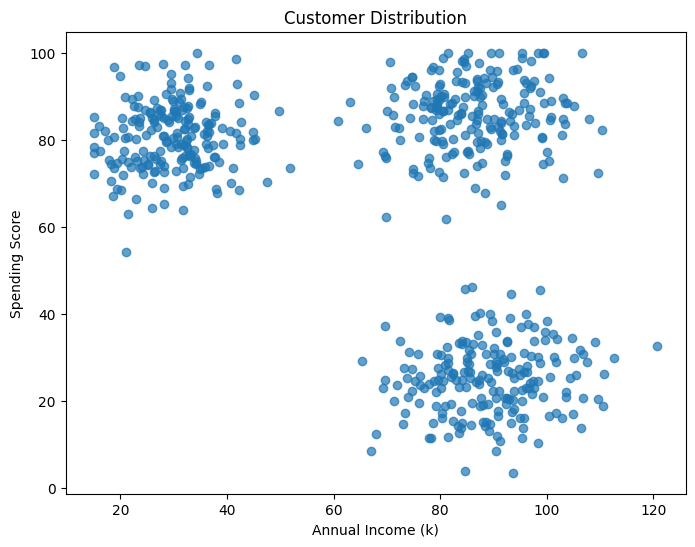

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X["annual_income_k"],
    X["spending_score"],
    alpha=0.7
)

plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")

plt.show()

## 5. Elbow Method

In [15]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[493.6612225455825, 104.78073635275291, 89.20403155659567, 74.62768172212496, 64.90664194466716, 58.007936338630714, 51.23907345929896, 44.80488813273406, 40.18324696332537]


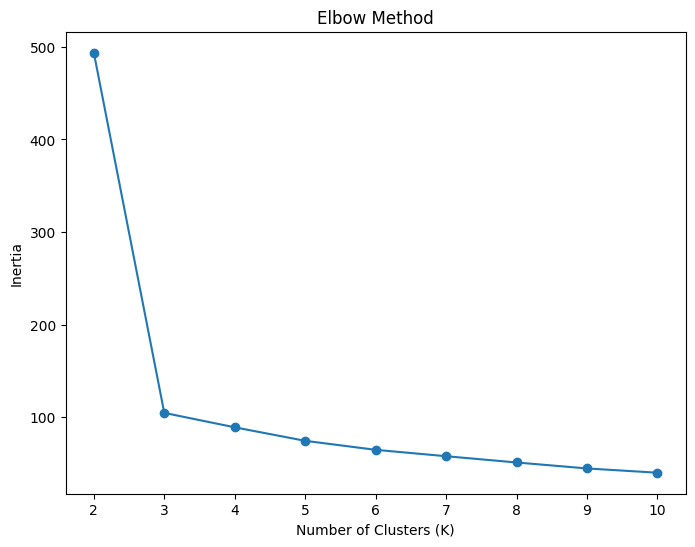

In [16]:
plt.figure(figsize=(8, 6))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

## 6. Silhouette Analysis

In [17]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[np.float64(0.580488780518429), np.float64(0.735716940561882), np.float64(0.6024869457825948), np.float64(0.47215202967038283), np.float64(0.33736297289551925), np.float64(0.342112609632823), np.float64(0.33990835914476003), np.float64(0.35688229946042477), np.float64(0.3548150890660352)]


In [18]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.5805
K = 3: Silhouette Score = 0.7357
K = 4: Silhouette Score = 0.6025
K = 5: Silhouette Score = 0.4722
K = 6: Silhouette Score = 0.3374
K = 7: Silhouette Score = 0.3421
K = 8: Silhouette Score = 0.3399
K = 9: Silhouette Score = 0.3569
K = 10: Silhouette Score = 0.3548


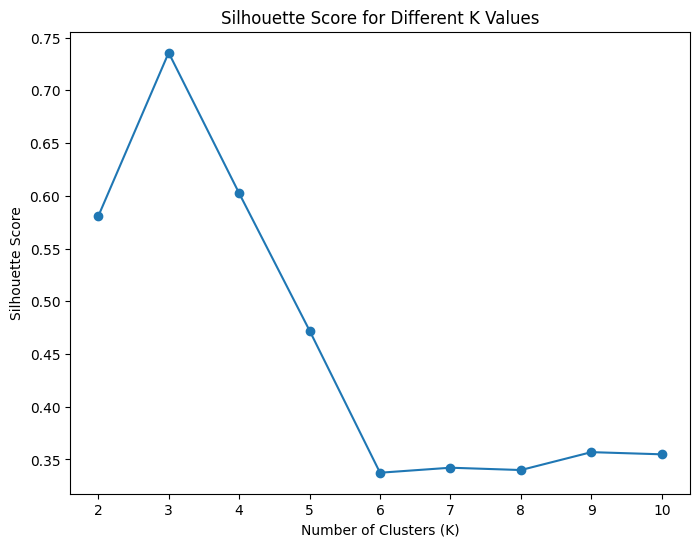

In [19]:
plt.figure(figsize=(8, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

# Selection of Optimal Number of Clusters

The Elbow Method shows a significant reduction in inertia from K = 2 to K = 3, after which the reduction becomes comparatively smaller.

The Silhouette Score reaches its highest value at K = 3 (approximately 0.74), indicating good separation and cohesion of the clusters.

Therefore, K = 3 is selected as the optimal number of clusters for the Customer Persona Segmentation model.

## 8. K-Means Clustering

In [20]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = final_kmeans.fit_predict(X_scaled)

print("K-Means model trained successfully!")

K-Means model trained successfully!


In [21]:
df["cluster"] = clusters

df.head()

,annual_income_k,spending_score,cluster
0,34.0,82.9,1
1,28.9,84.5,1
2,35.2,88.7,1
3,42.2,88.4,1
4,28.1,69.0,1


In [22]:
cluster_counts = df["cluster"].value_counts().sort_index()

print(cluster_counts)

cluster
0    200
1    200
2    200
Name: count, dtype: int64


## 9. Cluster Analysis

In [23]:
cluster_summary = df.groupby("cluster")[
    ["annual_income_k", "spending_score"]
].mean()

cluster_summary

,annual_income_k,spending_score
cluster,,
0,86.2840,85.9550
1,29.7140,80.6345
2,89.1445,25.0720


## 10. Customer Persona Interpretation

Based on the K-Means cluster analysis, three customer personas were identified:

### Cluster 0 — High-Value Customers
- Average annual income: 86.284k
- Average spending score: 85.955
- High-income and high-spending customers.
- Represents customers with strong purchasing behaviour.

### Cluster 1 — High-Engagement Customers
- Average annual income: 29.714k
- Average spending score: 80.635
- Lower-income but high-spending customers.
- Represents customers with strong engagement despite comparatively lower income.

### Cluster 2 — Low-Engagement High-Income Customers
- Average annual income: 89.145k
- Average spending score: 25.072
- High-income but low-spending customers.
- Represents customers with relatively low spending behaviour despite higher income.

## 11. Cluster Visualization

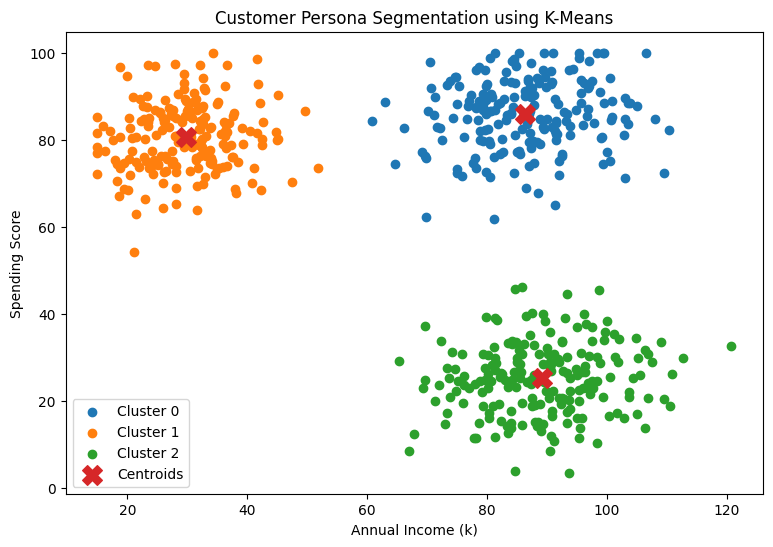

In [24]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df[df["cluster"] == 0]["annual_income_k"],
    df[df["cluster"] == 0]["spending_score"],
    label="Cluster 0"
)

plt.scatter(
    df[df["cluster"] == 1]["annual_income_k"],
    df[df["cluster"] == 1]["spending_score"],
    label="Cluster 1"
)

plt.scatter(
    df[df["cluster"] == 2]["annual_income_k"],
    df[df["cluster"] == 2]["spending_score"],
    label="Cluster 2"
)

plt.scatter(
    scaler.inverse_transform(final_kmeans.cluster_centers_)[:, 0],
    scaler.inverse_transform(final_kmeans.cluster_centers_)[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score")
plt.title("Customer Persona Segmentation using K-Means")
plt.legend()

plt.show()

## 12. Model Evaluation

In [25]:
final_silhouette_score = silhouette_score(
    X_scaled,
    clusters
)

print(f"Final Silhouette Score: {final_silhouette_score:.4f}")

Final Silhouette Score: 0.7357


## 13. Model Saving

In [26]:
joblib.dump(
    final_kmeans,
    "../models/kmeans_model.pkl"
)

print("K-Means model saved successfully!")

K-Means model saved successfully!


In [27]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


## 14. Saving Processed Results

In [29]:
import os

print(os.getcwd())

C:\Users\selva\Downloads\Procode\Customer-Persona-Segmentation\notebooks


In [30]:
import os

os.makedirs("../data/processed", exist_ok=True)

print("Processed data folder is ready!")

Processed data folder is ready!


In [31]:
df.to_csv("../data/processed/customer_clusters.csv", index=False)

print("Clustered customer data saved successfully!")

Clustered customer data saved successfully!


In [33]:
os.makedirs("../reports", exist_ok=True)
cluster_summary.to_csv("../reports/cluster_summary.csv")

print("Cluster summary saved successfully!")

Cluster summary saved successfully!
